# Tutorial: Reinforcement Learning in GridWorld

## Table of Contents
1.  [**The Environment**](##1-the-environment-gridworld-navigation---a-simple-game)
    * Modeling the GridWorld as a Markov Decision Process (MDP).
    * Defining States ($S$), Actions ($A$), Transitions ($P$), and Rewards ($R$).
    * *Key Issue:* Handling boundary conditions (Walls vs. Wrapping).
2.  [**Policy Evaluation**](##2.-Policy-Evaluation:-How-good-is-guessing?)
    * Evaluating a Uniform Random Policy.
    * Solving the Bellman Expectation Equation iteratively.
    * Visualizing the Value Function ($V_\pi$).
    * Observations for the Value Function, and why $V(\rm terminal) = 0$
3.  [**Q-Learning Control**](##3.-Q-Learning:-Finding-the-Optimal-Path)
    * Model-free learning (no prior knowledge of $P$ or $R$).
    * Implementing $\epsilon$-greedy exploration.
    * Visualizing the Optimal Policy ($\pi^*$) and Learning Curve.
4.  [**Discussion**](##4.-Discussion:-Why-is-the-Value-Function-Asymmetric?)
    * Analyzing why the original code produced asymmetric results.
    * Implementing "True Grid Physics" to fix boundary issues.

---

### Code Overview
This notebook implements a classic Reinforcement Learning environment from scratch using **NumPy**.

* **Environment (`n_states`, `P`, `R`):**
    * We manually construct the Transition Probability Matrix ($P$) and Reward Matrix ($R$) for a $4 \times 4$ grid.
    * State 0 is the "Hole" (Terminal, -1 reward).
    * State 15 is the "Goal" (Terminal, +10 reward).
    * All other steps incur a "living penalty" of -1.
* **Algorithms:**
    1.  **Iterative Policy Evaluation:** We compute the exact value of being in any state assuming the agent moves randomly. This uses _dynamic programming_ concepts.
    2.  **Q-Learning:** We train an agent to find the *best* path. The agent explores the grid, updates its estimates ($Q$-values) based on rewards received, and eventually converges to the optimal path.
* **Visualization:**
    * We use **Matplotlib** and **Seaborn** to create heatmaps of the Value Functions.
    * We use helper functions to print the Policy (arrows indicating the best direction to move).


## 1. The Environment: GridWorld Navigation - a simple game

In this tutorial, we will solve a classic Reinforcement Learning problem: **GridWorld**.

Imagine a robot navigating a $4 \times 4$ room. The goal is to reach the target destination while minimizing the time taken.

\
**The Problem Description:**
* **States ($S$):** The grid has 16 cells (numbered 0 to 15).
    * **State 0:** Top-left corner (Terminal state, treated as a "hole" or penalty zone in our reward structure).
    * **State 15:** Bottom-right corner (The Goal, Terminal state).
* **Actions ($A$):** The agent can move in 4 directions:
    * 0: **Up**
    * 1: **Down**
    * 2: **Left**
    * 3: **Right**
* **Rewards ($R$):**
    * Reaching State 15 (Goal): **+10**
    * Reaching State 0 (Penalty Zone): **-1**
    * Every other step (Living Penalty): **-1** (This encourages the agent to find the shortest path).
* **Dynamics ($P$):** The environment is deterministic. If you try to move Up, you go Up (unless you hit a wall, in which case you stay put).

\
**The Mathematical Framework: MDP**

We model this as a **Markov Decision Process (MDP)**, defined by the tuple $\langle S, A, R, P, \gamma \rangle$:
* $S$: The set of states.
* $A$: The set of actions.
* $R$: The reward function $R(s, a, s')$.
* $P$: The transition probability $P(s' | s, a)$.
* $\gamma$: The discount factor (set to 0.9), which determines how much the agent cares about future rewards versus immediate rewards.


\
**Here, we have 16 states and 4 actions**

![Gridworld](https://mribatet.perso.math.cnrs.fr/CentraleNantes/Reinforcement/Gridworld.png)

<sub>*Image Credit: [Mathieu Ribatet, Ecole Centrale de Nantes](https://mribatet.perso.math.cnrs.fr/CentraleNantes/Reinforcement/Gridworld.html)*</sub>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Helper Functions for Visualization ---

def print_policy_arrows(policy, n_rows=4, n_cols=4):
    """
    Visualizes the policy with arrows.
    0: Up, 1: Down, 2: Left, 3: Right
    """
    symbols = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    grid = policy.reshape(n_rows, n_cols)

    print("-" * 25)
    for row in grid:
        row_str = " | ".join([symbols[action] for action in row])
        print(f"| {row_str} |")
        print("-" * 25)

def plot_value_heatmap(V, n_rows=4, n_cols=4, title="Value Function Heatmap"):
    """
    Plots a heatmap of the state values with clear state index labeling.
    """
    v_grid = V.reshape(n_rows, n_cols)

    # Create labels that show: "S{index}\n{value}"
    # This makes it clear which square corresponds to which state ID
    state_indices = np.arange(n_rows * n_cols).reshape(n_rows, n_cols)
    annot_labels = np.array([[f"S{idx}\n{val:.2f}" for idx, val in zip(row_idx, row_val)]
                             for row_idx, row_val in zip(state_indices, v_grid)])

    plt.figure(figsize=(8, 6))
    sns.heatmap(v_grid,
                annot=annot_labels,
                fmt="",
                cmap="coolwarm",
                cbar_kws={'label': 'Expected Value'},
                xticklabels=["Col 0", "Col 1", "Col 2", "Col 3"],
                yticklabels=["Row 0", "Row 1", "Row 2", "Row 3"])

    plt.title(title)
    plt.xlabel("Grid Columns")
    plt.ylabel("Grid Rows")
    plt.show()

In [2]:
np.set_printoptions(threshold=np.inf)  # print everything

# Define the gridworld environment
n_states = 16  # Total number of states in the grid (4x4 grid)
n_actions = 4  # Total number of possible actions: up, down, left, right

# Initialize the transition probabilities matrix
P = np.zeros((n_states, n_actions, n_states))
# Initialize the rewards matrix
R = np.zeros((n_states, n_actions, n_states))
gamma = 0.9  # Discount factor for future rewards

# Fill in the transition probabilities and rewards for each state and action
for s in range(n_states):  # Loop over all states
    for a in range(n_actions):  # Loop over all actions
        if s == 0 or s == 15:  # If the current state is a terminal state
            P[s, a, s] = 1  # Stay in the same state with probability 1
        else:
            if a == 0:  # Up
                s_prime = s - 4
            elif a == 1:  # Down
                s_prime = s + 4
            elif a == 2:  # Left
                s_prime = s - 1
            else:  # Right
                s_prime = s + 1

            # Ensure the new state is within bounds
            if s_prime < 0: s_prime = 0
            if s_prime > 15: s_prime = 15

            # Assign rewards
            if s_prime == 0:
                R[s, a, s_prime] = -1  # Penalty
            elif s_prime == 15:
                R[s, a, s_prime] = 10  # Goal Reward
            else:
                R[s, a, s_prime] = -1  # Living Penalty

            P[s, a, s_prime] = 1

print("Environment initialized.")

Environment initialized.


In this specific implementation, P is a 3D NumPy array with the shape (16, 4, 16).

Each entry $P[s, a, s']$ represents the probability that the agent will move from its current state ($s$) to a new state ($s'$) after taking a specific action ($a$).

The output is displayed as a series of 16 blocks (one for each state). Inside each block, there are 4 rows representing the actions:
- State ($s$): Each large block of brackets corresponds to one of the 16 cells in the $4 \times 4$ grid.
- Action ($a$): Within each state block, there are 4 rows:
  - Row 0: "Up" action
  - Row 1: "Down" action
  - Row 2: "Left" action
  - Row 3: "Right" action
- Next State ($s'$): Each row contains 16 numbers. A 1.0 indicates a 100% probability of landing in that specific state, while 0.0 means it is impossible.

In [3]:
print(P)

[[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0

To understand the numbers in the output above, let's look at two specific states from the terminal output:

**1. The Terminal State (e.g., State 0)**

```Python
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 0 (Up)
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 1 (Down)
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 2 (Left)
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] # Action 3 (Right)
```

In **State 0**, the 1.0 is always at index 0 regardless of the action. This confirms the code's logic for terminal states: once the agent reaches state 0, it stays there forever (a "self-loop"), effectively ending the episode.

\
**2. A Movement State (e.g., State 1)**

```Python
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 0 (Up) -> Leads to State 0
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 1 (Down) -> Leads to State 5
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] # Action 2 (Left) -> Leads to State 0
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] # Action 3 (Right) -> Leads to State 2
```

- **Up (Action 0)**: Moving "Up" from the top row (State 1) would go out of bounds. The code handles this by setting the result to State 0 (the 1.0 is at index 0).
- **Down (Action 1)**: In a $4 \times 4$ grid, moving down adds 4 to the current index. $1 + 4 = 5$, so you see the 1.0 at the **6th position (index 5)**.
- **Right (Action 3)**: Moving right adds 1. $1 + 1 = 2$, so you see the 1.0 at the **3rd position (index 2)**.

## 2. Policy Evaluation: How good is guessing?

Before we try to find the _best_ strategy, let's evaluate a simple one.

We define a **Uniform Random Policy**
- This means that regardless of where the robot is, it will choose Up, Down, Left, or Right with equal probability ($25\%$).


\
**The Goal of Policy Evaluation**

We want to calculate the **Value Function** $V_\pi(s)$ for this random policy.
- $V_\pi(s)$ tells us: _"If I start in state $s$ and walk randomly forever until a terminal state is hit, how much total reward can I expect to accumulate?"_

\
**The Bellman Expectation Equation**

We use an iterative algorithm to estimate these values based on the Bellman equation:

$$V_{k+1}(s) = \sum_{a} \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right],$$

which means that value of a state is the weighted average of the immediate reward plus the discounted value of the next state.


[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
(State  0 ) Actions [0.25 0.25 0.25 0.25]
(State  1 ) Actions [0.25 0.25 0.25 0.25]
(State  2 ) Actions [0.25 0.25 0.25 0.25]
(State  3 ) Actions [0.25 0.25 0.25 0.25]
(State  4 ) Actions [0.25 0.25 0.25 0.25]
(State  5 ) Actions [0.25 0.25 0.25 0.25]
(State  6 ) Actions [0.25 0.25 0.25 0.25]
(State  7 ) Actions [0.25 0.25 0.25 0.25]
(State  8 ) Actions [0.25 0.25 0.25 0.25]
(State  9 ) Actions [0.25 0.25 0.25 0.25]
(State  10 ) Actions [0.25 0.25 0.25 0.25]
(State  11 ) Actions [0.25 0.25 0.25 0.25]
(State  12 ) Actions [0.25 0.25 0.25 0.25]
(State  13 ) Actions [0.25 0.25 0.25 0.25]
(State  14 ) Actions [0.25 0.25 0.25 0.

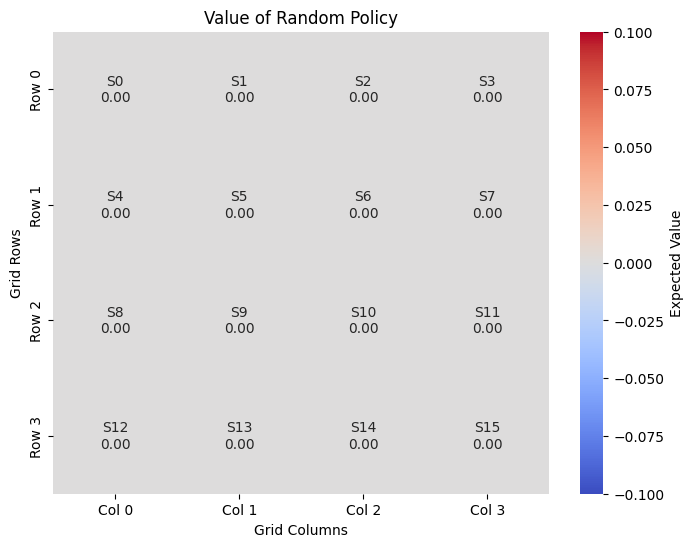

Final Value Function (Random Policy):
[[ 0.         -2.36003667 -2.84272002 -2.80977835]
 [-2.8029887  -3.20188587 -3.02005022 -2.39774911]
 [-2.00161733 -1.60308234 -0.53564463  1.61922876]
 [ 2.35218862  3.05878273  5.06770607  0.        ]]


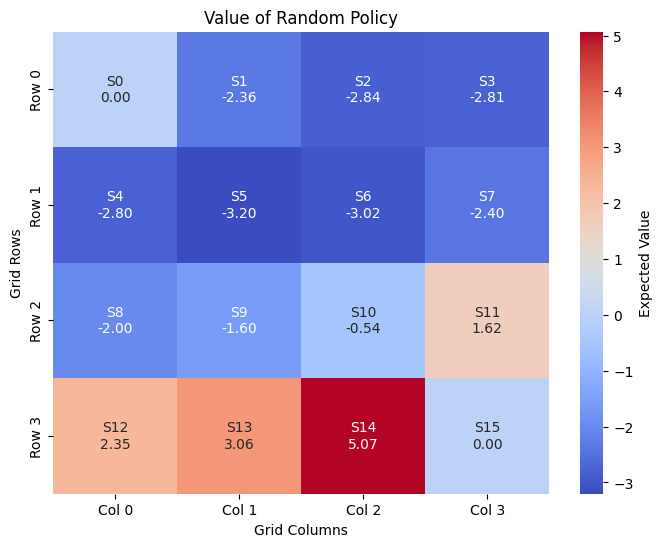

In [4]:
# Define a uniformly random policy
policy = np.ones((n_states, n_actions)) / n_actions

print(policy)

for s in range(n_states):
  print("(State ", s, ") Actions", policy[s])

# Initialize Value Function to zeros for all states
V = np.zeros(n_states)
tolerance = 1e-6  # Convergence tolerance, stops the algorithm when changes are small

print("Initial value function:")
print(V.reshape(4, 4))  # Reshape for better readability, assuming a 4x4 grid
plot_value_heatmap(V, title="Value of Random Policy")

# Policy Evaluation Loop
while True:
    delta = 0    # Initialize delta to track the maximum change in value function across all states in an iteration.
    for s in range(n_states):  # Iterate over all states.
        v = V[s]  # Store the current value of the state
        bellman_update = 0  # This will accumulate the sum of expected returns.
        for a in range(n_actions):  # Iterate over all actions
            for s_prime in range(n_states):  # Iterate over all possible next states
                # Calculate the expected return using the Bellman equation for policy evaluation: V(s) = Sum[ prob(a|s) * prob(s'|s,a) * (R + gamma * V(s')) ]
                bellman_update += policy[s, a] * P[s, a, s_prime] * (R[s, a, s_prime] + gamma * V[s_prime])
        V[s] = bellman_update  # Update the value function with the computed expected retur
        delta = max(delta, abs(v - V[s]))  # Update delta with the largest change in value function for any state
    if delta < tolerance:  # If the maximum change is less than the tolerance, the value function has converged
        break

print("Final Value Function (Random Policy):")
print(V.reshape(4, 4))
plot_value_heatmap(V, title="Value of Random Policy")

**Observations**: Random Policy Value Function

- **_The Diffusion of Penalty_**: States closer to State 0 (like S1, S4, and S5) have significantly lower values. This is because a random agent is highly likely to "stumble" into the penalty zone before finding the goal.

- **_The Reachability of the Goal_**: Values increase as you move toward the bottom-right (S15). Even with random moves, being physically closer to the +10 reward increases the mathematical expectation of hitting it.

- **_Symmetry Breaking_**: Note that S1 and S4 might have different values despite being equidistant from S0. This is often due to the "boundary physics" (clamping at the edges vs. the terminal logic of State 0).

\
**Why Terminal States Have Value 0**

Note that the value function at S0 and S15 are both 0. This is because in RL, the Value Function $V(s)$ represents the total expected **_future_** reward an agent can accumulate starting from state $s$.

Once an agent enters a terminal state, the episode ends immediately; there is no "future" from which to collect more rewards. The reward for *reaching* the terminal state (+10 for S15, -1 for S0) is credited to the *previous* state, not the terminal state itself.

**Example:** If you move from S14 to S15 (the goal), you get +10 reward. This +10 updates the value of S14, not S15. Once in S15, all future rewards are 0, so $V(S15) = 0$.

## 3. Q-Learning: Finding the Optimal Path

Now we want to solve the **Control Problem**: Finding the optimal policy $\pi^*$ that yields the maximum possible reward.

We will use **Q-Learning**, a model-free algorithm. Unlike the previous section, the agent does not know the transition matrix $P$ or reward matrix $R$ beforehand; it must explore the grid to learn them.

\
**The Q-Value**

Instead of learning the value of a state $V(s)$, we learn the value of an _action_ in a state, denoted as $Q(s, a)$. This represents the expected return of taking action $a$ in state $s$ and then acting optimally afterwards.

\
**The Algorithm**

1. **Initialize** $Q(s, a)$ to zero.
    
2. **Explore** the environment using an **$\epsilon$-greedy policy**:
    
    - With probability $\epsilon$ (exploration), choose a random action.
        
    - With probability $1-\epsilon$ (exploitation), choose the action with the highest current Q-value.
        
3. **Update** the Q-values using the **Bellman Optimality Equation**:
    

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

**Key Hyperparameters:**

- **Learning Rate ($\alpha$):** How much we update our old beliefs based on new information.
    
- **Discount Factor ($\gamma$):** Importance of future rewards (0.9).
    
- **Exploration Rate ($\epsilon$):** How often we try random moves to discover new paths.

\
**Uniqueness of the Solution**

Is the optimal solution unique?
- The **Optimal Value Function** ( $V^*$ ) is unique. (There is only one "true" maximum score for each state).
- The **Optimal Policy ($\pi^*$)** is **NOT** necessarily unique. (There can be multiple paths of the same length to the goal).

We will demonstrate this below by running two agents with different random seeds.

Training Agent 1 (Seed 42)...
Optimal policy:
[[0 1 3 1]
 [1 1 3 1]
 [1 1 3 1]
 [1 1 1 0]]
Optimal value function:
[[ 0.    4.58  4.58  6.2 ]
 [ 6.2   6.2   6.2   8.  ]
 [ 8.    8.    8.   10.  ]
 [10.   10.   10.    0.  ]]
Training Agent 2 (Seed 99)...
Optimal policy:
[[0 1 1 1]
 [1 1 1 1]
 [1 1 3 1]
 [1 1 1 0]]
Optimal value function:
[[ 0.    4.58  4.58  6.2 ]
 [ 6.2   6.2   6.2   8.  ]
 [ 8.    8.    8.   10.  ]
 [10.   10.   10.    0.  ]]

--- Comparing Value Functions ---
Max difference between Value Functions: 0.00000

--- Visualizing Value Function (Agent 1) ---


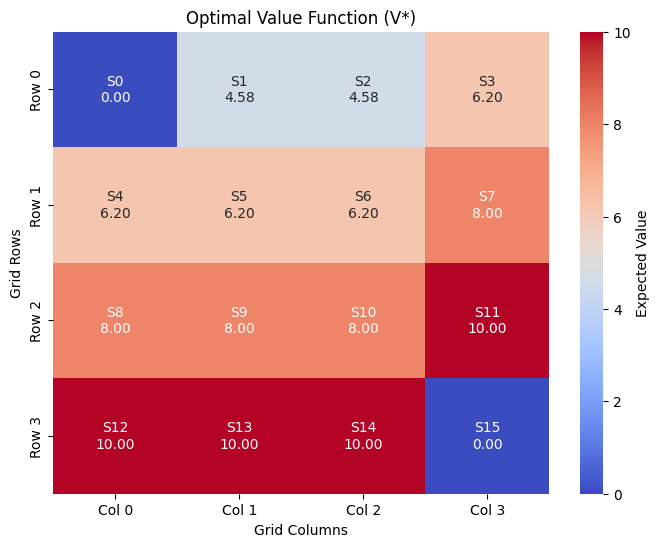


--- Visualizing Policy (Agent 1) ---
-------------------------
| ↑ | ↓ | → | ↓ |
-------------------------
| ↓ | ↓ | → | ↓ |
-------------------------
| ↓ | ↓ | → | ↓ |
-------------------------
| ↓ | ↓ | ↓ | ↑ |
-------------------------


In [5]:
def run_q_learning(seed=None, n_episodes=10000):
    """Runs Q-learning and returns the derived policy and value function.

      seed: random seed number
      n_episodes: Number of episodes for the agent to learn from
    """
    if seed:
        np.random.seed(seed)

    # Initialize the Q-values matrix with zeros for all state-action pairs.
    # Q[s, a] represents the value of taking action a in state s.
    Q = np.zeros((n_states, n_actions))
    # print("Q", Q)

    alpha = 0.1  # Learning rate, determining how much new information overrides old information.
    epsilon = 0.1  # Epsilon-greedy exploration probability

    # Loop over each episode.
    for episode in range(n_episodes):
        # Randomly select an initial state for the beginning of the episode.
        s = np.random.randint(n_states)
        # Continue the episode until reaching a terminal state (0 or 15 in this gridworld).
        while s not in [0, 15]:
            # Epsilon-greedy action selection:
            # With probability epsilon, select a random action (exploration).
            if np.random.uniform() < epsilon:
                a = np.random.randint(n_actions)
            else:
                # With probability 1 - epsilon, select the action with the highest Q-value.
                a = np.argmax(Q[s, :])

            # Take the selected action, observe the next state and reward.
            # The next state is chosen based on the transition probabilities P[s, a, :].
            s_prime = np.random.choice(range(n_states), p=P[s, a, :])
            r = R[s, a, s_prime]  # The reward received for the (s, a, s') transition

            # Update the Q-value for the current state-action pair using the Q-learning formula.
            # This incorporates the immediate reward and the discounted value of the best future action.
            Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s_prime, :]) - Q[s, a])
            # Move to the next state.
            s = s_prime

    # After learning, extract the optimal policy from the Q-values.
    # The optimal action for each state is the one with the highest Q-value.
    policy = np.argmax(Q, axis=1)
    # print("updated Q: ", Q)
    print("Optimal policy:")
    # Print the optimal policy, reshaped into the grid format for easy visualization.
    print(policy.reshape(4, 4))

    # optimal value function
    V = np.max(Q, axis=1)
    print("Optimal value function:")
    print(V.reshape(4, 4))

    return policy, V

# --- Experiment: Run Agents with different seeds ---
print("Training Agent 1 (Seed 42)...")
policy_1, V_1 = run_q_learning(seed=42)

print("Training Agent 2 (Seed 99)...")
policy_2, V_2 = run_q_learning(seed=99)

# --- Check Uniqueness ---
print("\n--- Comparing Value Functions ---")
diff = np.max(np.abs(V_1 - V_2))
print(f"Max difference between Value Functions: {diff:.5f}")

print("\n--- Visualizing Value Function (Agent 1) ---")
plot_value_heatmap(V_1, title="Optimal Value Function (V*)")

print("\n--- Visualizing Policy (Agent 1) ---")
print_policy_arrows(policy_1)

**Observations**: Optimal Value Function (Q-Learning)

- **_Path Concentration_**: Unlike the random policy, the optimal value function will show a clear "ridge" of high values along the shortest path to State 15.

- **_Sharp Gradients_**: There is a drop in value for states adjacent to S0. The optimal agent learns to "fear" the states that could lead to an accidental transition into the penalty zone.

### 3.1 Learning curve

 A **Learning Curve** is a fundamental visualization in RL used to track an agent's progress and performance over time. It essentially shows how much the agent "improves" as it gains more experience from interacting with the environment.

In the context of our GridWorld tutorial, the learning curve reveals three critical phases of the agent's journey:

1. The Axes: What are we measuring?
    * **X-Axis (Episodes):** This represents time or experience. One "episode" is one full run of the game, starting from a random position and ending when the agent hits a terminal state (the penalty hole at S0 or the goal at S15).
    * **Y-Axis (Total Reward/Return):** This is the sum of all rewards the agent collected during that specific episode.
    * Since every step costs **-1** (the living penalty), a lower (more negative) score means the agent took a long, inefficient path or fell into the hole.
    * A higher score means the agent found the goal quickly.


2. The Three Phases of the Curve
    - **Phase A: Initial Randomness**
      - At the very beginning (left side of the graph), the curve is usually at its lowest point.
        * **What's happening:** The agent knows nothing. Its Q-table is full of zeros. It moves almost entirely at random.
        * **Result:** It wanders around the grid for a long time, accumulating many `-1` penalties before finally hitting a terminal state by accident. The total reward is low

    - **Phase B:Learning & Discovery**
      - You will notice a sharp upward slope in the graph.
        * **What's happening:** The agent has discovered the  goal at S15. Through the Q-learning update rule, that reward is starting to "leak" back into the neighboring states. The agent is beginning to prefer actions that lead toward the goal.
        * **Result:** The episodes become shorter, the penalties decrease, and the total reward rises rapidly.

    - **Phase C: Convergence (The Plateau)**
      - Finally, the curve flattens out at a high value.
        * **What's happening:** The agent has found the **Optimal Policy**. It now knows the shortest possible path from almost every state.
        * **Result:** Even if we train it for 10,000 more episodes, the reward won't go much higher because it is already acting as efficiently as the physics of the grid allow.

3. Why is the curve zig-zag (noise)?
    - Because of **$ϵ$-greedy exploration**:
      * Even an "expert" agent with a perfect Q-table will occasionally choose a random, "bad" move with probability  (10% in our code).
      * One random move might send the agent away from the goal, causing a sudden "dip" in that episode's reward.

4. What a "Good" Curve Looks Like
    * **Steepness:** A steeper slope means the agent is a "fast learner" (often due to a higher learning rate ).
    * **Final Height:** The higher the plateau, the better the final strategy. If the curve plateaus at a very low number, your agent might be stuck in a "local optium" (like consistently falling into the hole because it's the closest exit).

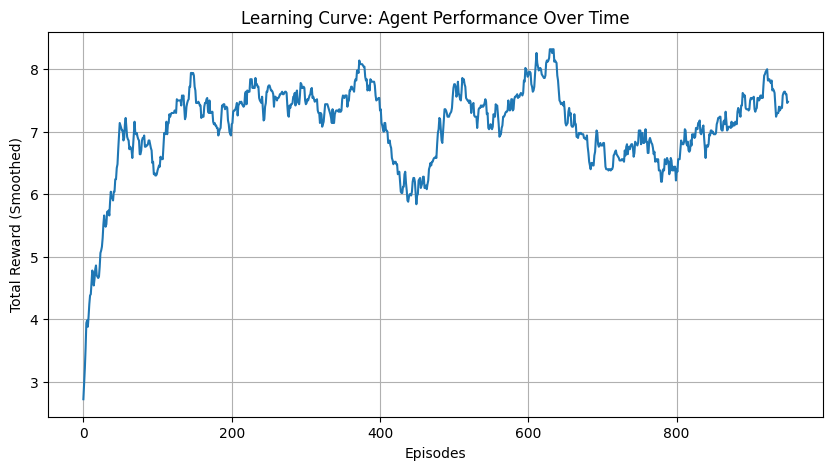

In [6]:
# --- Learning Curve Visualization ---
# Let's visualize how the agent improves over time

Q = np.zeros((n_states, n_actions))
rewards_history = []
alpha = 0.1
epsilon = 0.1

for episode in range(1000):
    s = np.random.randint(n_states)
    total_reward = 0
    while s not in [0, 15]:
        if np.random.uniform() < epsilon:
            a = np.random.randint(n_actions)
        else:
            a = np.argmax(Q[s, :])

        s_prime = np.random.choice(range(n_states), p=P[s, a, :])
        r = R[s, a, s_prime]

        Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s_prime, :]) - Q[s, a])
        s = s_prime
        total_reward += r
    rewards_history.append(total_reward)

# Smooth the plot
window_size = 50
smoothed_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward (Smoothed)")
plt.title("Learning Curve: Agent Performance Over Time")
plt.grid(True)
plt.show()

# you can play around with learning rate and epsion to see how the learning curve changes

### 3.2 Some additional notes if you are interested

##### 3.2.1 Effect of $\alpha$ (Learning Rate)

The learning rate  determines how much the agent "updates" its current belief based on new information.

* **High $\alpha$ (e.g., 0.5 – 0.9):**
  * **The Curve:** The initial slope is very steep. The agent learns from its first few rewards very quickly.
  * **The Risk:** The curve may become unstable or "jittery" even after many episodes. High  makes the agent overreact to a single lucky or unlucky move, preventing the Q-values from ever perfectly converging to the true optimum.


* **Low $\alpha$ (e.g., 0.01 – 0.05):**
  * **The Curve:** The slope is very gentle. It may take thousands of extra episodes before you see the "knee" where the agent discovers the goal.
  * **The Benefit:** Once it does learn, the value function is extremely stable and accurate. It is less sensitive to the "noise" of random transitions.



**Summary:** Think of $\alpha$ as the **"Confidence"** of the agent. High  means "I trust my most recent experience completely," while low  means "I want to see something happen many times before I believe it."

---

##### 3.2.2 Effect of $\epsilon$ (Exploration Rate)

The exploration rate  controls the trade-off between trying new things and sticking to what the agent already knows.

* **High $\epsilon$ (e.g., 0.3 – 0.5):**
  * **The Curve:** You will see a very "noisy" or "fuzzy" line.
  * **The Plateau:** The final reward plateau will be **lower**. Even if the agent knows the perfect path, it is forced to take a random (and likely bad) action  of the time.
  * **The Discovery:** The agent will likely find the goal very early because it is constantly wandering into new areas.


* **Low $\epsilon$ (e.g., 0.01 – 0.05):**
  * **The Curve:** The line is much smoother.
  * **The Risk:** The agent might never find the goal if it "greedily" settles on a suboptimal path too early. If it finds a path that gives a small reward, it might stop exploring other paths that could have led to a much higher reward.



**Summary:** Think of  as **"Curiosity."** Too much curiosity makes the agent act "silly" even when it’s an expert; too little curiosity makes the agent "stubborn" and close-minded to better options.

---

##### 3.2.3 Summary Table

| Hyperparameter | Increase (↑) | Decrease (↓) |
| --- | --- | --- |
| **Learning Rate ($\alpha$)** | **Faster** initial learning; potential **instability**. | **Slower** learning; higher **stability**. |
| **Exploration ($\epsilon$ )** | **Noisier** curve; **lower** final reward; finds goal **sooner**. | **Smoother** curve; **higher** potential reward; may get **stuck** in bad habits. |

---

##### 3.2.4 More advanced setting: "Epsilon Decay"

In advanced RL, we don't keep  constant. We start with a **high $\epsilon$** (to explore everything) and gradually **decay** it toward zero as the agent becomes an expert. This gives you the best of both worlds: a fast discovery of the goal and a high, stable final plateau.

### 4. Discussion: Why is the Value Function Asymmetric?

Someone in the class asked:
- Why the Value Function is asymmetric, even though the environment seems symmetric (4 by 4 grid). For example, State 1 and State 4 are both adjacent to the start (State 0), but they have different values. Why?
- Also, following our discussions, the student further noted what happens if we changed the rules so that hitting a wall makes the robot 'bounce back' or stay in place (instead of being clamped to State 0 or State 15 as currently defined in our code), would it become symmetric?

These are all great questions. I want to further address them here.

Note that the asymmetry in our code comes from two specific behaviors in our original code:
1. **Vertical Clamping**: Moving Up from the top row calculates a negative index (e.g., 1 - 4 = -3), which our code clamps to State 0. This forces the agent into the penalty zone.
2. **Horizontal Wrapping**: Moving Left from the left edge (e.g., State 4) calculates 4 - 1 = 3. Since 3 is a valid state index, the agent essentially "wraps around" to the row above rather than hitting a wall.

To achieve true symmetry (where $V(S1) \approx V(S4)$), we need to implement **True Grid Physics**, where hitting any boundary keeps the agent in its current cell.

Let's test this hypothesis by redefining our environment dynamics ($P$) and re-running Policy Evaluation.

Symmetric Value Function:
[[ 0.         -4.65195528 -6.02963773 -6.21470614]
 [-4.65195528 -5.54932151 -5.45764876 -4.71742419]
 [-6.02963773 -5.45764876 -3.51539004 -0.13210725]
 [-6.21470614 -4.71742419 -0.13210725  0.        ]]


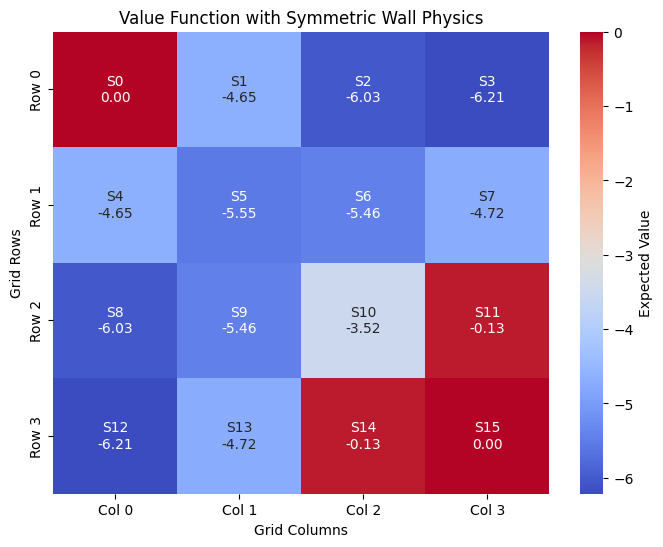

In [7]:
def get_symmetric_P_and_R(n_rows=4, n_cols=4):
    """
    Creates dynamics P and Reward R using 'True Grid Physics'.
    - No wrapping around rows.
    - Hitting a wall keeps you in the same state.
    """
    n_states = n_rows * n_cols
    n_actions = 4
    P_sym = np.zeros((n_states, n_actions, n_states))
    R_sym = np.zeros((n_states, n_actions, n_states))

    for s in range(n_states):
        # Convert 1D index to 2D (row, col) coordinates
        row = s // n_cols
        col = s % n_cols

        for a in range(n_actions):
            # Terminal states loop to themselves
            if s == 0 or s == 15:
                s_prime = s
                reward = 0
            else:
                # Calculate tentative new coordinates
                new_row, new_col = row, col

                if a == 0:   # Up
                    new_row = max(row - 1, 0)
                elif a == 1: # Down
                    new_row = min(row + 1, n_rows - 1)
                elif a == 2: # Left
                    new_col = max(col - 1, 0)
                elif a == 3: # Right
                    new_col = min(col + 1, n_cols - 1)

                # Convert back to 1D index
                s_prime = new_row * n_cols + new_col

                # Define Rewards based on landing state
                if s_prime == 0:
                    reward = -1 # Penalty
                elif s_prime == 15:
                    reward = 10 # Goal
                else:
                    reward = -1 # Living Penalty

            # Set Probabilities and Rewards
            P_sym[s, a, s_prime] = 1.0
            R_sym[s, a, s_prime] = reward

    return P_sym, R_sym

# 1. Initialize Symmetric Environment
P_sym, R_sym = get_symmetric_P_and_R()

# 2. Define Random Policy
policy_random = np.ones((16, 4)) / 4

# 3. Run Policy Evaluation
V_sym = np.zeros(16)
tolerance = 1e-6

while True:
    delta = 0
    for s in range(16):
        v = V_sym[s]
        # Bellman update using the NEW P_sym and R_sym
        bellman_update = 0
        for a in range(4):
            for s_prime in range(16):
                bellman_update += policy_random[s, a] * P_sym[s, a, s_prime] * (R_sym[s, a, s_prime] + 0.9 * V_sym[s_prime])
        V_sym[s] = bellman_update
        delta = max(delta, abs(v - V_sym[s]))
    if delta < tolerance:
        break

# 4. Visualize Results
print("Symmetric Value Function:")
print(V_sym.reshape(4, 4))
plot_value_heatmap(V_sym, title="Value Function with Symmetric Wall Physics")

**Observation**: Notice that the heatmap is now perfectly symmetric along the diagonal (from top-left to bottom-right):
- $V(S1)$ is roughly equal to $V(S4)$.
- $V(S2)$ is roughly equal to $V(S8)$.

This confirms that the asymmetry was indeed caused by the specific boundary rules (Clamping vs. Wrapping) we used in the initial setup.

\
 **The same results apply to the Optimal Value Function ($V^*$) learned via Q-Learning.** In fact, the effect is often more pronounced in Q-Learning because the optimal agent will actively exploit the "bugs" in the environment.

\
*Why Q-Learning is also Asymmetric here*:

In our original code, for example:
1. State 4 (Left Edge): Moving Left wraps you around to State 3. An optimal agent effectively discovers a "wormhole" that teleports it safely to the other side of the map. This increases the value of State 4.
2. State 1 (Top Edge): Moving Up clamps you to State 0 (Death/Penalty). An optimal agent learns that moving Up is suicide. It loses a degree of freedom compared to State 4. Because State 4 has a safe "shortcut" (wrapping) and State 1 has a "death trap" (clamping), the optimal agent values State 4 higher than State 1 ($V^*(S4) > V^*(S1)$), breaking symmetry.